En este notebook se va a trabajar con el algoritmo Apriori, con el objetivo de aplicar reglas que nos permitan observar patrones de co-compra. Para este ejercicio, en donde estamos trabajando en una tienda física, trabajar con Apriori se enfoca en el desarrollo de inteligencia de negocio (BI). 

Mediante el análisis de las cestas, es posible crear relaciones entre productos complementarios. Descubriendo estas relaciones, se puede actuar en consecuencia para colocar de forma estratégica una malgama de productos cerca de la caja. De esta forma, se busca aumentar la venta cruzada y aumentar el valor de ticket medio.

In [ ]:
import pandas as pd

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules


import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
from pyvis.network import Network

In [4]:
df = pd.read_pickle('data/transacciones_limpio.pkl')

print(f'Filas: {len(df):,}')
print(f'Productos: {df["product_name"].nunique()}')
print(f'Tickets: {df["ticket_number"].nunique()}')

Filas: 100,000
Productos: 138
Tickets: 9540


Una vez se han cargado los datos, es momento de empezar a construir las cestas y la matriz binaria que recibe Apriori. Para construir la matriz se emplea el método TransactionEncoder.

Como el caso de uso es BI, vamos a trabajar sobre todo el conjunto de datos, no es necesario realizar un train/test.

In [6]:
cestas = df.groupby('ticket_number')['product_name'].apply(list) # creamos cestas y almacenamos en listas

print(f'Nº cestas: {len(cestas)}')

Nº cestas: 9540


In [8]:
te = TransactionEncoder() # instanciamos objeto
te_array = te.fit_transform(cestas)

cestas_binarias = pd.DataFrame(te_array, columns=te.columns_)

print(f'Forma: {cestas_binarias.shape}')

Forma: (9540, 138)


Con todo listo, es hora de llamar al método apriori. Como estamos en un método que trabaja con reglas, no existe ningún tipo de optimización, el ajuste de parámetros dependerá del enfoque de negocio.

Para empezar a trabajar con los datos, vamos aplicar un *min_support*, que es el umbral de frecuencia mínimo con el que debe aparecer cada combinación para que sea considerada una opción.

In [15]:
itemsets = apriori(
    cestas_binarias, # matriz binaria de cestas
    min_support=0.02, # valor mínimo de frecuencia para tener en cuenta las combinaciones
    use_colnames=True
)

itemsets['longitud'] = itemsets['itemsets'].apply(len)

print(f'Itemsets encontrados: {len(itemsets)}')
round(itemsets.sort_values('support', ascending=False).head(10),4)

Itemsets encontrados: 12877


,support,itemsets,longitud
60,0.6490,frozenset({MERMELADA FRESA 350G}),1
7,0.5426,frozenset({AZUCAR BLANCO 1KG}),1
15,0.5252,frozenset({CARNE PICADA MIXTA 500G}),1
213,0.5048,"frozenset({AZUCAR BLANCO 1KG, MERMELADA FRESA ...",2
363,0.4165,"frozenset({CARNE PICADA MIXTA 500G, MERMELADA ...",2
13,0.3845,frozenset({CAFE MOLIDO 250G}),1
49,0.3779,frozenset({LECHE ENTERA BRIK 1L}),1
308,0.3654,"frozenset({CAFE MOLIDO 250G, MERMELADA FRESA 3...",2
188,0.3619,"frozenset({AZUCAR BLANCO 1KG, CARNE PICADA MIX...",2
186,0.3548,"frozenset({AZUCAR BLANCO 1KG, CAFE MOLIDO 250G})",2


El valor de support que devuelve este objeto indica la frecuencia con la que aparece ese producto/combinación. Si nos fijamos en la columna longitud, esta nos indica cuantos productos hay en esa combinación. 

Teniendo en cuenta que el objetivo son los patrones de co-compra, solo nos interesan todos los itemsets que tengan una longitud mayor a 1, es decir, que muestren combinaciones y no popularidad pura del producto. En el momento que se apliquen las reglas de asociación, aquellas líneas que presentan longitud 1 serán filtradas. Con este filtro, pasaremos de 12877 itemsets encontrados, a un tamaño mucho menor. Si quisieramos reducir o aumentar este número, habría que cambiar el valor de *min_support*

In [16]:
reglas = association_rules(itemsets, metric='lift', min_threshold=1.0)
print(f'Reglas generadas: {len(reglas)}')

Reglas generadas: 469562


Una vez tenemos el itemset generado, procedemos a aplicar las reglas de asociación sin apenas ningún tipo de ajuste. En este escenario, nuestra métrica estrella es el lift, que se encarga de medir cuanta más fuerza tiene una regla de asociación en comparación con el puro azar. Ejecutando las reglas básicas, se obtienen un total de 469562 reglas, un número demasiado grande como para ser manejable. Para reducir el tamaño de las reglas generadas se aplicarán ciertos filtros

Como interpertar lift:
- Si lift > 1 nos encontramos en el escenario ideal, la asociación es positiva. Comprar el producto A aumenta la probabilidad de comprar el producto B. Se produce el cross-selling que buscamos con los productos complementarios.
- Si lift = 1 nos encontramos en un escenario de independencia total. No hay regla, es decir, comprar A no influye en comprar B. Se tratan de eventos aleatorios
- Si lift <1 nos encontramos en un escenario de asociación negativa. Situación que se busca evitar totalmente, ya que estariíamos ante productos sustitutivos y no complementarios. 

In [23]:
# Aplicación de reglas y filtrado
reglas_filtradas = reglas[
    (reglas['antecedents'].apply(len) == 1) & # un solo producto como antecedente
    (reglas['consequents'].apply(len) == 1) & # un solo producto como consecuente
    (reglas['support'] >= 0.03) &  #  combinación presente en al menos el 3% de las cestas
    (reglas['lift'] >= 2) & # métrica estrella, asocicación entre productos
    (reglas['confidence'] >= 0.5) # confianza de la cesta. 50%
].sort_values('lift', ascending=False)

reglas_filtradas['antecedente'] = reglas_filtradas['antecedents'].apply(lambda x: list(x)[0])
reglas_filtradas['consecuente'] = reglas_filtradas['consequents'].apply(lambda x: list(x)[0])

print(f'Reglas tras aplicar filtros: {len(reglas_filtradas)}')
round(reglas_filtradas[['antecedente', 'consecuente', 'support', 'confidence', 'lift']].head(15),4)

Reglas tras aplicar filtros: 143


,antecedente,consecuente,support,confidence,lift
1396,PIENSO PERRO 4KG,SNACKS PERRO 200G,0.0316,0.6543,16.9633
1397,SNACKS PERRO 200G,PIENSO PERRO 4KG,0.0316,0.8179,16.9633
995,PIENSO GATO 2KG,JUGUETE PERRO,0.0308,0.7696,14.2569
994,JUGUETE PERRO,PIENSO GATO 2KG,0.0308,0.5709,14.2569
997,JUGUETE PERRO,PIENSO PERRO 4KG,0.0368,0.6816,14.1348
996,PIENSO PERRO 4KG,JUGUETE PERRO,0.0368,0.7630,14.1348
663,JUGUETE PERRO,CHAMPU MASCOTAS 250ML,0.0303,0.5612,13.6569
662,CHAMPU MASCOTAS 250ML,JUGUETE PERRO,0.0303,0.7372,13.6569
661,COMIDA HUMEDA PERRO PACK 4,CHAMPU MASCOTAS 250ML,0.0331,0.5593,13.6113
660,CHAMPU MASCOTAS 250ML,COMIDA HUMEDA PERRO PACK 4,0.0331,0.8061,13.6113


Es importante tener en cuenta que las reglas aplicadas son totalmente arbitrárias, es decir, cada negocio aplicará reglas según sus necesidades, no existe una respuesta única. Para este escenario se han aplicado las siguientes reglas:
- antecedentes: se trata del producto antecedente que lleva al siguiente. Puede ser un producto o más. Aquí se aplica un solo antecedente para simplificar el problema y que resulte más legible.
- consecuentes: se trata del producto consecuente con el que conecta el producto de antecedentes. Al igual que en antecedentes, el valor no tiene porque ser 1.
- support: frecuencia de aparición de la combinación en las cestas. Se indica un valor mínimo de 3%
- confidence: nos indica la confianza con la que se compran estos productos. Es importante ser cauteloso con este valor, ya que una confianza del 90% no indica que los productos resulten complementarios. Alguien que compra auga puede comprar un snack con una confianza del 80% por ejemplo, pero pueden mostrar un lift de 1.05, siendo una compra meramente casual. Se indica un valor mínimo del 50%
- lift: métrica estrella, nos indica la fuerza que tienen los productos entre si, queremos que sea siempre lo más alto posible. Se indica un valor mínimo de 2

Con estos valores seleccionados para filtrar el itemset, se obtienen unas 143 reglas, un número mucho más manejable.

In [ ]:
# identificación de clusters
G = nx.from_pandas_edgelist(reglas_filtradas, 'antecedente', 'consecuente', edge_attr='lift')
comunidades = nx.community.greedy_modularity_communities(G)
print(f'Clusters detectados: {len(comunidades)}')
for i, com in enumerate(comunidades):
    print(f'Cluster {i+1}: {list(com)[:6]}')

Clusters detectados: 8
Cluster 1: ['HELADO CHOCOLATE 1L', 'NACHOS 200G', 'CERVEZA PACK 6', 'AGUA MINERAL PACK 6', 'EMPANADA ATUN', 'ACEITUNAS RELLENAS 350G']
Cluster 2: ['PATATA KG', 'LECHUGA ICEBERG UD', 'PECHUGA POLLO BANDEJA', 'GRANOLA BIO 400G', 'LECHE AVENA 1L', 'BEBIDA SOJA 1L']
Cluster 3: ['PAPILLA CEREALES 600G', 'TOALLITAS BEBE PACK 3', 'POTITO FRUTA VARIADA', 'CREMA PAÑAL 100ML', 'CHUPETE PACK 2', 'LECHE INFANTIL CONTINUACION']
Cluster 4: ['FILM TRANSPARENTE 30M', 'PAPEL ALUMINIO 30M', 'VELAS AROMATICAS PACK 3', 'SUAVIZANTE CONCENTRADO 1.5L', 'PAPEL HIGIENICO PACK 12', 'FRIEGASUELOS 1.5L']
Cluster 5: ['CHAMPU MASCOTAS 250ML', 'JUGUETE PERRO', 'PIENSO GATO 2KG', 'PIENSO PERRO 4KG', 'SNACKS PERRO 200G', 'COMIDA HUMEDA PERRO PACK 4']
Cluster 6: ['LECHE SEMIDESNATADA 1L', 'CEREALES DESAYUNO 500G', 'PLATANO KG']
Cluster 7: ['CAFE MOLIDO 250G', 'GALLETAS MARIA 800G']
Cluster 8: ['PASTA ESPAGUETI 500G', 'QUESO RALLADO 200G']


In [ ]:

# --- 1. Detección de clusters ---
G = nx.from_pandas_edgelist(reglas_filtradas, "antecedente", "consecuente", edge_attr="lift")
comunidades = nx.community.greedy_modularity_communities(G)
n_clusters = len(comunidades)

# --- 2. Generación automática de colores (uno por cluster) ---
colormap = plt.colormaps["tab20"].resampled(n_clusters)

color_nodo = {}
for i, comunidad in enumerate(comunidades):
    color_hex = mcolors.to_hex(colormap(i))
    for producto in comunidad:
        color_nodo[producto] = color_hex

# --- 3. Construcción del grafo interactivo ---
net = Network(height="650px", width="100%", bgcolor="#ffffff", font_color="#333333")

for _, fila in reglas_filtradas.iterrows():
    ant = fila["antecedente"]
    con = fila["consecuente"]
    lift = fila["lift"]

    net.add_node(ant, label=ant, color=color_nodo.get(ant, "#B5D4F4"), size=20)
    net.add_node(con, label=con, color=color_nodo.get(con, "#B5D4F4"), size=20)
    net.add_edge(ant, con, value=float(lift), title=f"Lift: {lift:.2f}")

# --- 4. Física y guardado ---
net.barnes_hut(gravity=-3000, central_gravity=0.3, spring_length=150)
net.save_graph("grafo_cocompra_v2.html")
print("Guardado grafo_cocompra_v2.html")

Guardado grafo_cocompra_v2.html


Como la tabla de valores resulta muy abstracta, se procede a identificar clusteres de clientes. En este proceso se logran identificar 8 grupos diferentes.

- Grupo 1: perfil tipo fiesta/apertivos
- Grupo 2: perfil tipo cocina/frescos
- Grupo 3: perfil bebé
- Grupo 4: perfil hogar/droguería
- Grupo 5: perfil mascotas
- Grupo 6: perfil desayuno
- Grupo 7: perfil café
- Grupo 8: perfil pasta

Observando los datos, tanto grupo 7 como 8 se pueden integrar en otros grupos. Esta es una decisión de negocio, si bien las matemáticas toman la decisión de separar estos productos en diferentes clúster, este modelo está enfocado a inteligencia de negocio y es la decisión que se puede tomar de agrupar esos dos grupos lo que hace brillar aún más el enfoque.

Con los clústers creados, se procede a crear un grafo que haga de la solución un elemento más visual y atractivo para quien se encargue de consumir esta solución

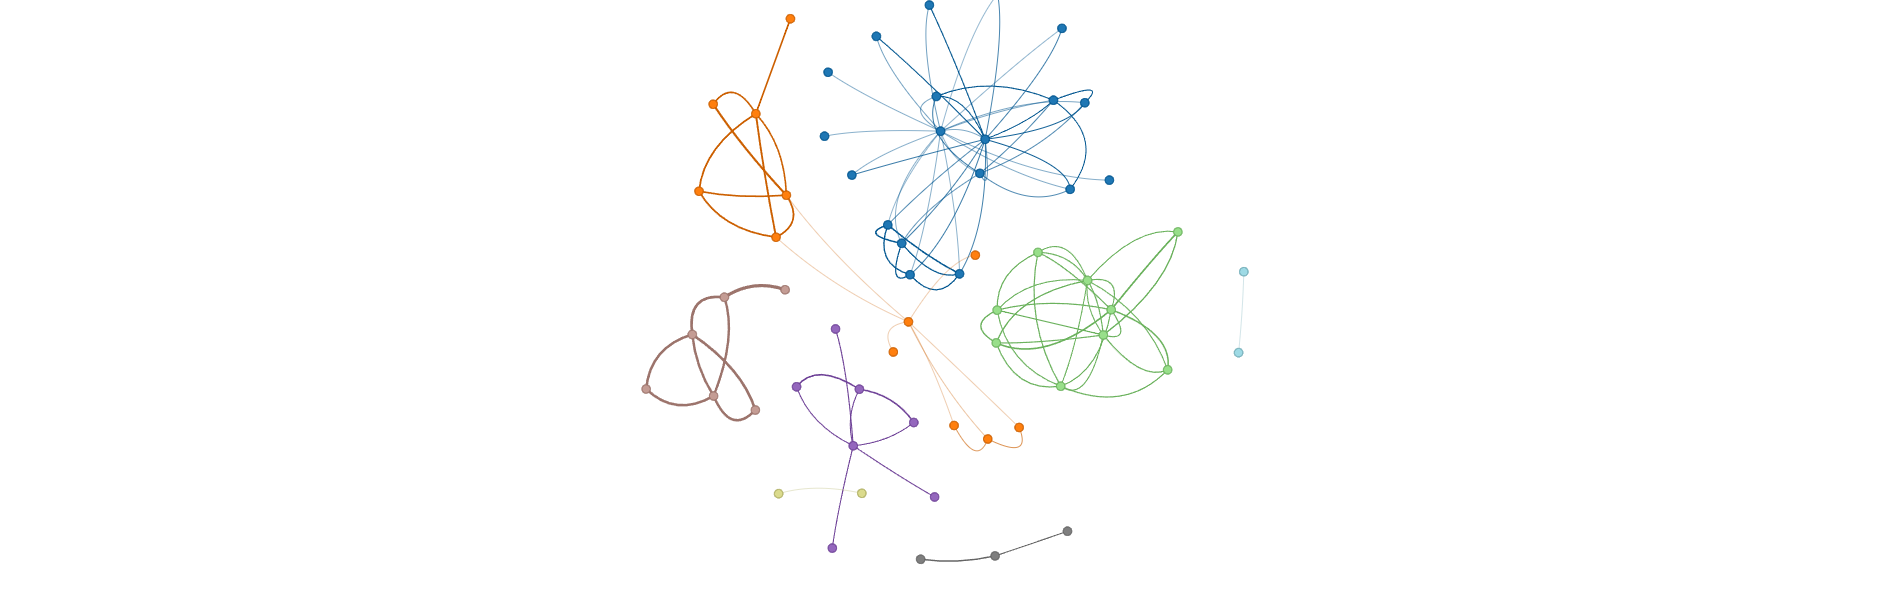